In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128*4*4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x)); x = self.pool(x)
        x = F.relu(self.conv2(x)); x = self.pool(x)
        x = F.relu(self.conv3(x)); x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [3]:
def train():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=128, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=100, shuffle=False, num_workers=2)

    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    # ---- TensorBoard ----
    log_dir = f"logs/cifar_torch/{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
    writer = SummaryWriter(log_dir=log_dir)

    # log model graph
    sample_inputs, _ = next(iter(trainloader))
    writer.add_graph(model, sample_inputs.to(device))

    EPOCHS = 8
    train_acc = []
    val_acc = []

    for epoch in range(EPOCHS):
        model.train()
        running = 0
        total = 0
        running_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            opt.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            opt.step()

            _, preds = outputs.max(1)
            running += (preds == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item() * labels.size(0)

        epoch_train_acc = running / total
        epoch_train_loss = running_loss / total
        train_acc.append(epoch_train_acc)

        # Validation
        model.eval()
        correct = 0
        total = 0
        val_loss = 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                _, preds = outputs.max(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                val_loss += loss.item() * labels.size(0)

        epoch_val_acc = correct / total
        epoch_val_loss = val_loss / total
        val_acc.append(epoch_val_acc)

        # ---- TensorBoard Scalars ----
        writer.add_scalar("Loss/train", epoch_train_loss, epoch)
        writer.add_scalar("Loss/val", epoch_val_loss, epoch)
        writer.add_scalar("Accuracy/train", epoch_train_acc, epoch)
        writer.add_scalar("Accuracy/val", epoch_val_acc, epoch)

        # ---- TensorBoard Histograms ----
        for name, param in model.named_parameters():
            writer.add_histogram(name, param, epoch)

        print(f"Epoch {epoch+1}/{EPOCHS} "
              f"train_acc={epoch_train_acc:.4f} "
              f"val_acc={epoch_val_acc:.4f}")

    writer.close()

    plt.figure()
    plt.plot(train_acc, label='train_acc')
    plt.plot(val_acc, label='val_acc')
    plt.legend()
    plt.title("PyTorch CNN accuracy")
    plt.show()

Epoch 1/8 train_acc=0.4562 val_acc=0.5618
Epoch 2/8 train_acc=0.6084 val_acc=0.6331
Epoch 3/8 train_acc=0.6781 val_acc=0.6727
Epoch 4/8 train_acc=0.7261 val_acc=0.7044
Epoch 5/8 train_acc=0.7574 val_acc=0.7305
Epoch 6/8 train_acc=0.7890 val_acc=0.7344
Epoch 7/8 train_acc=0.8098 val_acc=0.7522
Epoch 8/8 train_acc=0.8355 val_acc=0.7553


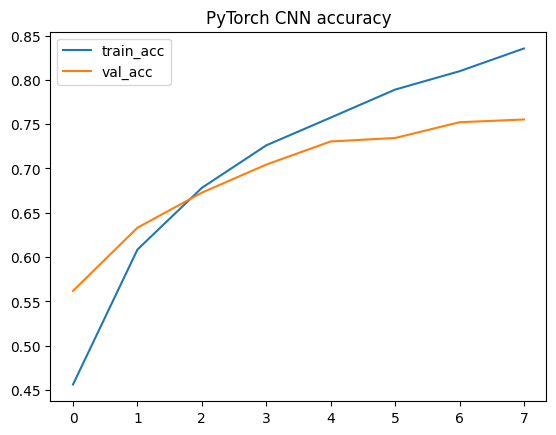

In [4]:
train()